## *Prática 3 - Índice de Proteção Social (2024)* <br>

In [2]:
%pip install geopandas

   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ------------------- -------------------- 9.4/19.2 MB 46.9 MB/s eta 0:00:01
   ---------------------------------------  19.1/19.2 MB 50.8 MB/s eta 0:00:01
   ---------------------------------------- 19.2/19.2 MB 44.5 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 32.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 25.4 MB/s  0:00:00

   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------------------------------- 0/5 [shapely]
   ---------------- ----------------------- 2/5 [pyproj]
   ---------------- ----------------------- 2/5 [pyproj]
   ------------------------ --------------- 3/5 [pyogrio]
   ---

In [9]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
import geopandas as gpd
#import geobr

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # Importe o módulo de cores
import seaborn as sns

# Configurações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [4]:
# Carregando os datasets
df = pd.read_excel('IPS_Brasil_2024.xlsx')
print("📊 Dataset carregado com sucesso!")

📊 Dataset carregado com sucesso!


In [11]:
# Primeiras 5 linhas
print("📋 Primeiras 5 linhas:")
display(df.head())

# Ultimas 5 linhas
print("\n📋 Últimas 5 linhas:")
display(df.tail())

📋 Primeiras 5 linhas:


,cod_municipio,Município,Estado,Região,Capital?,Amazônia Legal?,IPS Brasil 2024,Necessidades Humanas Básicas,Fundamentos do Bem-estar,Oportunidades,...,Praças e Parques em Áreas Urbanas,Trabalho Infantil,Paridade de Gênero na Câmara Municipal,Paridade de Negros na Câmara Municipal,Violência Contra Indígenas,Violência Contra Mulheres,Violência Contra Negros,Empregados com Ensino Superior,Mulheres Empregadas com Ensino Superior,Nota Média no Enem
0,1100015.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634,...,4.311155,6.751381,0.201822,0.817760,83.798883,544.600939,154.202005,50.698661,70.814513,545.588235
1,1100016.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634,...,4.311155,6.751381,0.201822,0.817760,83.798883,544.600939,154.202005,50.698661,70.814513,545.588235
2,1100023.0,Ariquemes (RO),RO,Norte,Não,Sim,55.974754,66.456103,62.352941,39.115218,...,3.520868,0.594354,0.457490,0.914038,103.092784,386.938274,187.129639,50.778764,69.084119,543.388624
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1100031.0,Cabixi (RO),RO,Norte,Não,Sim,51.364540,55.096942,54.275583,44.721095,...,5.112426,0.000000,0.449230,0.742219,0.000000,151.114469,57.971014,42.963371,62.500000,472.129333



📋 Últimas 5 linhas:


,cod_municipio,Município,Estado,Região,Capital?,Amazônia Legal?,IPS Brasil 2024,Necessidades Humanas Básicas,Fundamentos do Bem-estar,Oportunidades,...,Praças e Parques em Áreas Urbanas,Trabalho Infantil,Paridade de Gênero na Câmara Municipal,Paridade de Negros na Câmara Municipal,Violência Contra Indígenas,Violência Contra Mulheres,Violência Contra Negros,Empregados com Ensino Superior,Mulheres Empregadas com Ensino Superior,Nota Média no Enem
5567,5222005.0,Vianópolis (GO),GO,Centro-Oeste,Não,Não,57.934625,67.378830,63.125462,43.299584,...,6.150461,6.066863,0.661711,0.783443,0.000000,172.551102,314.465409,42.742927,58.726899,533.741481
5568,5222054.0,Vicentinópolis (GO),GO,Centro-Oeste,Não,Não,61.442588,70.350723,67.132475,46.844567,...,8.286562,5.431831,0.228102,0.866393,0.000000,23.413720,55.944056,49.873509,73.435744,512.793750
5569,5222203.0,Vila Boa (GO),GO,Centro-Oeste,Não,Não,55.536378,67.798739,62.955283,35.855112,...,1.981823,13.503982,0.926934,0.992215,0.000000,247.402276,232.288037,60.192616,87.821044,463.707143
5570,5222302.0,Vila Propício (GO),GO,Centro-Oeste,Não,Não,56.782527,73.611651,58.091254,38.644675,...,0.873410,5.998800,0.233001,0.448863,0.000000,21.637216,187.617261,51.861702,86.858432,496.479167
5571,5300108.0,Brasília (DF),DF,Centro-Oeste,Capital,Não,71.251897,79.158243,73.756042,60.841407,...,14.566773,4.435967,0.318436,0.772031,54.171181,518.243992,160.721091,242.426770,227.564199,568.346999


In [12]:
# Informações gerais sobre o dataset
print("ℹ️ Informações gerais do dataset:")
df.info()

ℹ️ Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 75 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   cod_municipio                                                    5571 non-null   float64
 1   Município                                                        5571 non-null   object 
 2   Estado                                                           5571 non-null   object 
 3   Região                                                           5571 non-null   object 
 4   Capital?                                                         5571 non-null   object 
 5   Amazônia Legal?                                                  5571 non-null   object 
 6   IPS Brasil 2024                                                  5571 non-null   float64
 7   Necessid

In [13]:
# Análise dos tipos de dados
print("📊 Tipos de dados por coluna:")
tipos_dados = df.dtypes.value_counts()
print(tipos_dados)

# Separando variáveis numéricas e categóricas
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n🔢 Variáveis numéricas ({len(numericas)}): {numericas}")
print(f"📝 Variáveis categóricas ({len(categoricas)}): {categoricas}")

📊 Tipos de dados por coluna:
float64    70
object      5
Name: count, dtype: int64

🔢 Variáveis numéricas (70): ['cod_municipio', 'IPS Brasil 2024', 'Necessidades Humanas Básicas', 'Fundamentos do Bem-estar', 'Oportunidades', 'Nutrição e Cuidados Médicos Básicos', 'Água e Saneamento', 'Moradia', 'Segurança Pessoal', 'Acesso ao Conhecimento Básico', 'Acesso à Informação e Comunicação', 'Saúde e Bem-estar', 'Qualidade do Meio Ambiente', 'Direitos Individuais', 'Liberdades Individuais e de Escolhas', 'Inclusão Social', 'Acesso à Educação Superior', 'Cobertura Vacinal (poliomielite)', 'Hospitalizações por Condições Sensíveis à Atenção Primária', 'Mortalidade Ajustada por Condições Sensíveis à Atenção Primária', 'Mortalidade Infantil até 5 anos', 'Subnutrição', 'Abastecimento de Água Via Rede de Distribuição', 'Esgotamento Sanitário Adequado', 'Índice de Abastecimento de Água', 'Índice de Perdas de Água na Distribuição', 'Domicílios com Coleta de Resíduos Adequada', 'Domicílios com Iluminaç

In [14]:
# Análise de valores ausentes
valores_ausentes = df.isnull().sum()
percentual_ausentes = (df.isnull().sum() / len(df)) * 100

ausentes_df = pd.DataFrame({
    'Coluna': df.columns,
    'Valores_Ausentes': valores_ausentes,
    'Percentual': percentual_ausentes
}).sort_values('Percentual', ascending=False)

print("❌ Análise de Valores Ausentes:")
display(ausentes_df[ausentes_df['Valores_Ausentes'] > 0])

if ausentes_df['Valores_Ausentes'].sum() == 0:
    print("✅ Não há valores ausentes no dataset.")

❌ Análise de Valores Ausentes:


,Coluna,Valores_Ausentes,Percentual
cod_municipio,cod_municipio,1,0.017947
Município,Município,1,0.017947
Estado,Estado,1,0.017947
Região,Região,1,0.017947
Capital?,Capital?,1,0.017947
...,...,...,...
Violência Contra Mulheres,Violência Contra Mulheres,1,0.017947
Violência Contra Negros,Violência Contra Negros,1,0.017947
Empregados com Ensino Superior,Empregados com Ensino Superior,1,0.017947
Mulheres Empregadas com Ensino Superior,Mulheres Empregadas com Ensino Superior,1,0.017947


In [15]:
# Verificando valores ausentes
df.isnull().sum()

# Fill empty and NaNs values with NaN
# df = df.fillna(np.nan)

cod_municipio                              1
Município                                  1
Estado                                     1
Região                                     1
Capital?                                   1
                                          ..
Violência Contra Mulheres                  1
Violência Contra Negros                    1
Empregados com Ensino Superior             1
Mulheres Empregadas com Ensino Superior    1
Nota Média no Enem                         1
Length: 75, dtype: int64

In [16]:
# Verificação de linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [17]:
# Removendo linhas completamente vazias e duplicadas
df = df.dropna(how='all')
df = df.drop_duplicates()
df.head()

,cod_municipio,Município,Estado,Região,Capital?,Amazônia Legal?,IPS Brasil 2024,Necessidades Humanas Básicas,Fundamentos do Bem-estar,Oportunidades,...,Praças e Parques em Áreas Urbanas,Trabalho Infantil,Paridade de Gênero na Câmara Municipal,Paridade de Negros na Câmara Municipal,Violência Contra Indígenas,Violência Contra Mulheres,Violência Contra Negros,Empregados com Ensino Superior,Mulheres Empregadas com Ensino Superior,Nota Média no Enem
0,1100015.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634,...,4.311155,6.751381,0.201822,0.817760,83.798883,544.600939,154.202005,50.698661,70.814513,545.588235
1,1100016.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634,...,4.311155,6.751381,0.201822,0.817760,83.798883,544.600939,154.202005,50.698661,70.814513,545.588235
2,1100023.0,Ariquemes (RO),RO,Norte,Não,Sim,55.974754,66.456103,62.352941,39.115218,...,3.520868,0.594354,0.457490,0.914038,103.092784,386.938274,187.129639,50.778764,69.084119,543.388624
4,1100031.0,Cabixi (RO),RO,Norte,Não,Sim,51.364540,55.096942,54.275583,44.721095,...,5.112426,0.000000,0.449230,0.742219,0.000000,151.114469,57.971014,42.963371,62.500000,472.129333
5,1100049.0,Cacoal (RO),RO,Norte,Não,Sim,61.845266,73.413193,65.875374,46.247232,...,2.331740,2.058583,0.000000,0.826865,101.492537,227.759612,44.749403,55.651300,70.904220,546.466073


In [18]:
# Mantendo o dataset com as primeiras 10 colunas para visualização
df = df.iloc[:, :10]
df.head()       

,cod_municipio,Município,Estado,Região,Capital?,Amazônia Legal?,IPS Brasil 2024,Necessidades Humanas Básicas,Fundamentos do Bem-estar,Oportunidades
0,1100015.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634
1,1100016.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634
2,1100023.0,Ariquemes (RO),RO,Norte,Não,Sim,55.974754,66.456103,62.352941,39.115218
4,1100031.0,Cabixi (RO),RO,Norte,Não,Sim,51.364540,55.096942,54.275583,44.721095
5,1100049.0,Cacoal (RO),RO,Norte,Não,Sim,61.845266,73.413193,65.875374,46.247232


In [19]:
# Renomeando colunas para facilitar a manipulação
df = df.rename(columns={'cod_municipio': 'Cod_Municipio','Município': 'Municipio', 'Região': 'Regiao','Capital?': 'Capital', 'Amazônia Legal?': 'Amaz_Legal','IPS Brasil 2024': 'IPS', 'Necessidades Humanas Básicas': 'NH_Basica', 'Fundamentos do Bem-estar': 'Fund_bEstar'})
df.head()

,Cod_Municipio,Municipio,Estado,Regiao,Capital,Amaz_Legal,IPS,NH_Basica,Fund_bEstar,Oportunidades
0,1100015.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634
1,1100016.0,Alta Floresta D'Oeste (RO),RO,Norte,Não,Sim,50.947109,59.696415,55.020277,38.124634
2,1100023.0,Ariquemes (RO),RO,Norte,Não,Sim,55.974754,66.456103,62.352941,39.115218
4,1100031.0,Cabixi (RO),RO,Norte,Não,Sim,51.364540,55.096942,54.275583,44.721095
5,1100049.0,Cacoal (RO),RO,Norte,Não,Sim,61.845266,73.413193,65.875374,46.247232


Pergunta 1 - Como se comportou o IPS no Brasil no ano de 2024

In [20]:
# Estatísticas descritiva do IPS
print("📊 Estatísticas descritivas do IPS:")
display(df['IPS'].describe())

📊 Estatísticas descritivas do IPS:


count    5571.000000
mean       58.062967
std         4.931448
min        37.632798
25%        54.933154
50%        58.096143
75%        61.551557
max        74.492824
Name: IPS, dtype: float64

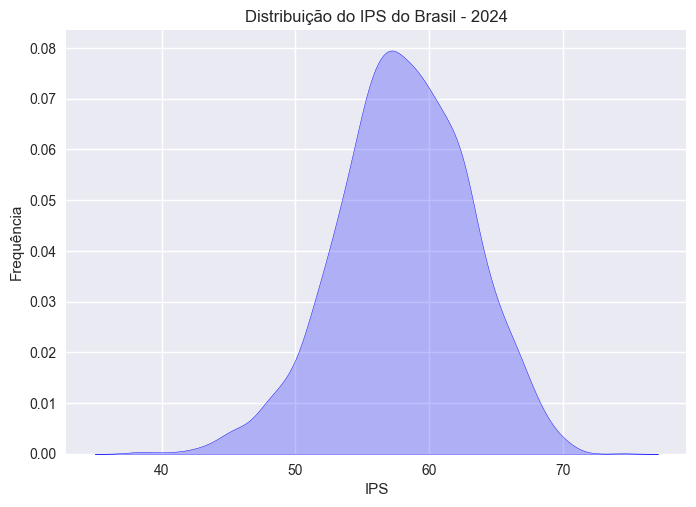

In [21]:
# Histograma do IPS
g = sns.kdeplot(df["IPS"], color="Blue", fill = True)
plt.title('Distribuição do IPS do Brasil - 2024')
plt.xlabel('IPS')
plt.ylabel('Frequência')
plt.show()

In [40]:
dfmunic = geobr.read_municipality(code_muni='all', year=2022)
dfmunic.head()

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,1100015.0,Alta Floresta D'oeste,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.96836 -12.13407, -61.96827..."
1,1100023.0,Ariquemes,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-63.18281 -10.13892, -63.18615..."
2,1100031.0,Cabixi,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.70518 -13.32474, -60.70904..."
3,1100049.0,Cacoal,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.3474 -11.50562, -61.34569 ..."
4,1100056.0,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.82417 -13.11156, -60.82289..."


In [41]:
df_Brasil_Geo = dfmunic.merge(df, left_on='code_muni', right_on='Cod_Municipio', how='left')


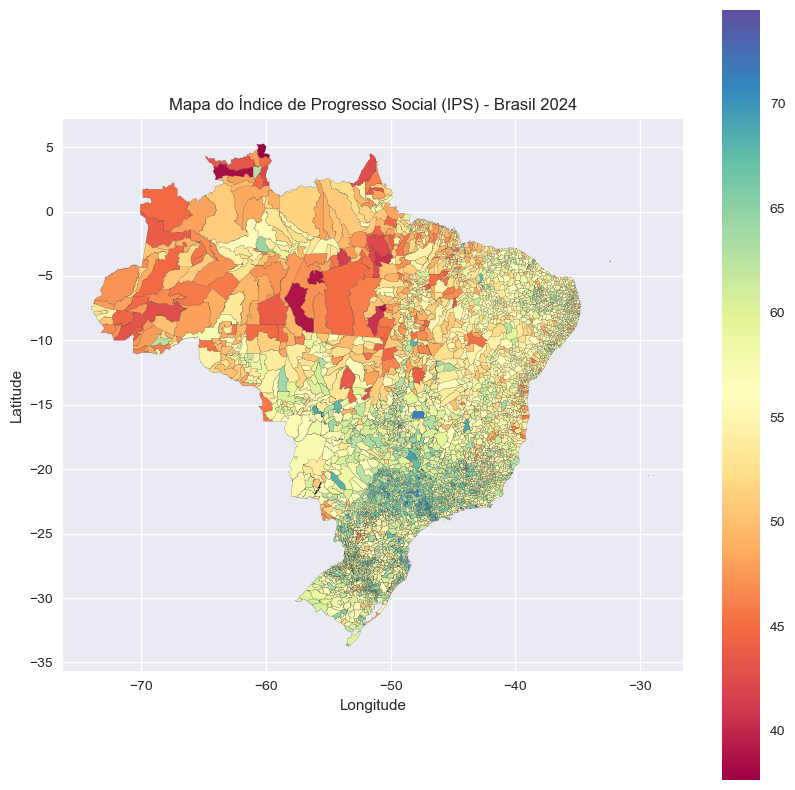

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
norm = mcolors.Normalize(vmin=df_Brasil_Geo['IPS'].min(), vmax=df_Brasil_Geo['IPS'].max())
df_Brasil_Geo.plot(column='IPS', cmap='Spectral', linewidth=0.1, ax=ax, edgecolor='0.1', norm=norm,legend=True)
plt.title('Mapa do Índice de Progresso Social (IPS) - Brasil 2024')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Pergunta 2 - Quais municípios tem o menor e maior IPS do Brasil?

In [43]:
# Encontra o índice do maior e menor IDH do Brasil
indice_maior_ips = df['IPS'].idxmax()
indice_menor_ips = df['IPS'].idxmin()

# Exibe o município com o maior e menor IDH
municipio_menor_ips = df.loc[indice_menor_ips, 'Municipio']
municipio_maior_ips = df.loc[indice_maior_ips, 'Municipio']
print(f"🌟 Município com o maior IPS: {municipio_maior_ips} (IPS: {df['IPS'].max()})")
print(f"🌟 Município com o menor IPS: {municipio_menor_ips} (IPS: {df['IPS'].min()})")

🌟 Município com o maior IPS: Gavião Peixoto (SP) (IPS: 74.4928239560098)
🌟 Município com o menor IPS: Uiramutã (RR) (IPS: 37.6327980351962)


Pergunta 3 - Há diferença entre as regiões do brasil em relação ao IPS

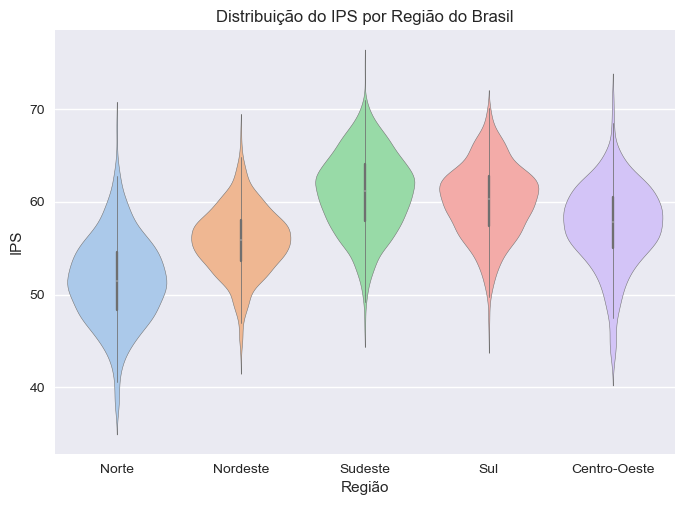

In [44]:
# Há diferença do valor do IPS por região do Brasil?
g = sns.violinplot(x="Regiao", y = "IPS",data = df, hue="Regiao", palette="pastel")
plt.title('Distribuição do IPS por Região do Brasil')
plt.xlabel('Região')
plt.ylabel('IPS')
plt.show()

Pergunta 4 - Há diferença do IPS entre os municípios que pertencem a Amazônia Legal e os que não pertencem?

In [45]:
# Estatística descritiva do IPS dos municípios da Amaz. Legal?
ldf1 = df.groupby('Amaz_Legal', as_index= False)['IPS']
ldf1.describe()

,Amaz_Legal,count,mean,std,min,25%,50%,75%,max
0,Não,4798.0,58.954333,4.359435,43.842398,55.909514,58.86235,62.062040,74.492824
1,Sim,773.0,52.530272,4.667462,37.632798,49.458509,52.60443,55.349149,68.474640


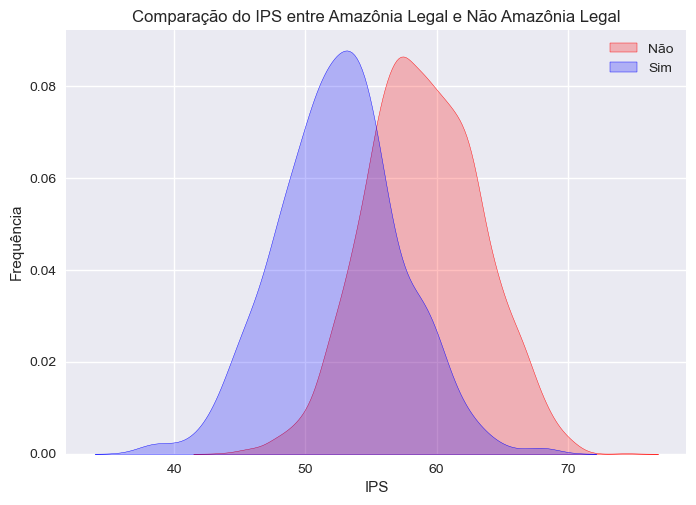

In [46]:
# Histograma do IPS dos municípios da Amaz. Legal
g = sns.kdeplot(df["IPS"][(df['Amaz_Legal'] == "Não")], color="Red", fill = True)
g = sns.kdeplot(df["IPS"][(df["Amaz_Legal"] == "Sim")], ax =g, color="Blue", fill = True)
g = g.legend(["Não","Sim"])
plt.title('Comparação do IPS entre Amazônia Legal e Não Amazônia Legal')
plt.xlabel('IPS')
plt.ylabel('Frequência')
plt.show()

Pergunta 5 - Há diferença do IPS entre municípios que são capitais e os que não são? Faça essa análise por região.

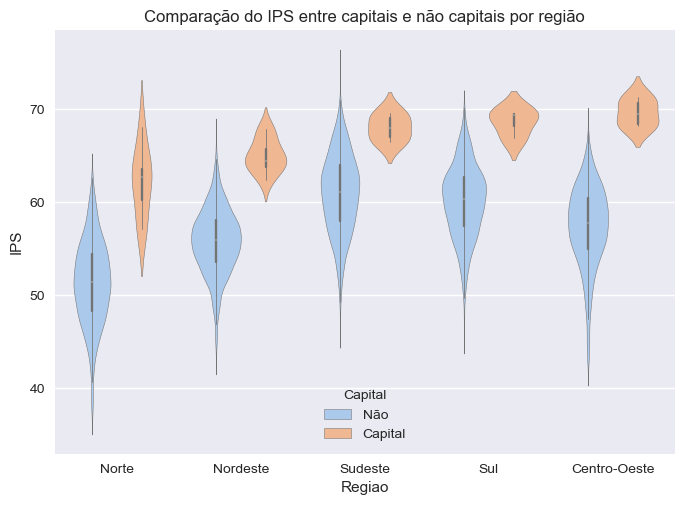

In [47]:
# Gráfico de Violino do IPS entre capitais e não capitais por região
g = sns.violinplot(x="Regiao", y = "IPS",data = df, hue='Capital', palette="pastel")
plt.title('Comparação do IPS entre capitais e não capitais por região')
plt.show()

Pergunta 6 - Há correlação entre os índices de Necessidades Humanas Básicas, Fundamentos de Bem-Estar e Oportunidades?

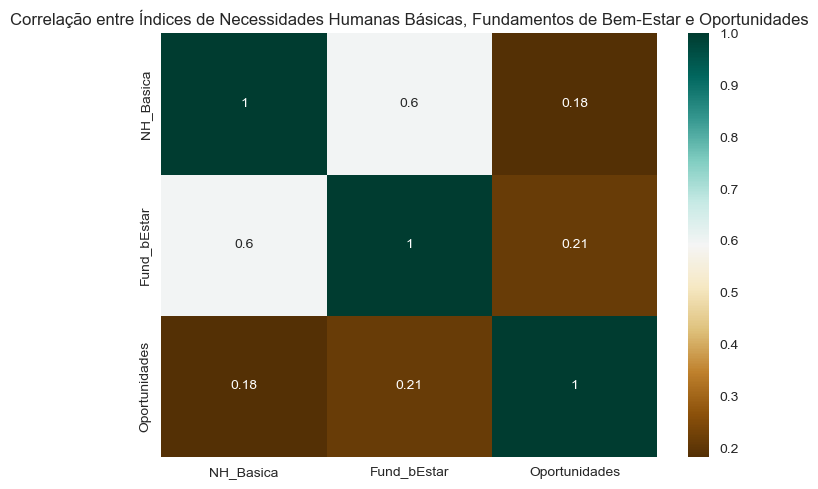

In [48]:
# Gráfico de correlação entre os índices de Necessidades Humanas Básicas, Fundamentos de Bem-Estar e Oportunidades
g = sns.heatmap(df[['NH_Basica','Fund_bEstar','Oportunidades']].corr(),cmap="BrBG",annot=True)
plt.title('Correlação entre Índices de Necessidades Humanas Básicas, Fundamentos de Bem-Estar e Oportunidades')
plt.show()

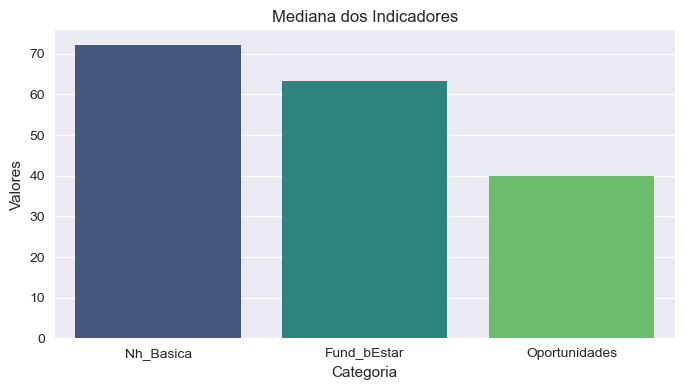

In [49]:
# 
dados = pd.DataFrame({
    'Categoria': ['Nh_Basica', 'Fund_bEstar', 'Oportunidades'],
    'Valores': [df['NH_Basica'].median(), df['Fund_bEstar'].median(), df['Oportunidades'].median()]
})

plt.figure(figsize=(8, 4))
sns.barplot(x='Categoria', y='Valores', data=dados, hue='Categoria', palette='viridis')
plt.title('Mediana dos Indicadores')
plt.show()

Pergunta 8 - Qual a média de cada um dos índices por região?

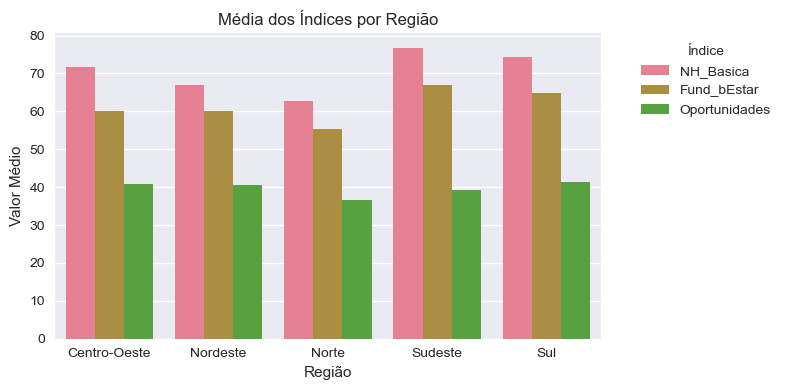

In [50]:
# Agrupar por regiao e calcular a média dos índices
df_grouped = df.groupby('Regiao')[['NH_Basica', 'Fund_bEstar', 'Oportunidades']].mean().reset_index()

# Transformar o dataframe para formato "long" (melted) para uso no seaborn
df_melted = df_grouped.melt(id_vars='Regiao', var_name='indice', value_name='valor')

# Criar gráfico de barras
plt.figure(figsize=(8, 4))
sns.barplot(data=df_melted, x='Regiao', y='valor', hue='indice')
plt.title('Média dos Índices por Região')
plt.ylabel('Valor Médio')
plt.xlabel('Região')
plt.legend(title='Índice', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()
